Amazon File loaded successfully!
Rows: 1507, Columns: 17
Total Records: 1507
Total Records after remove duplicates: 1351
  order_date  product_id                                       product_name  \
0   1/1/2025  B002PD61Y4  D-Link DWA-131 300 Mbps Wireless Nano USB Adap...   
2   1/1/2025  B002SZEOLG  TP-Link Nano USB WiFi Dongle 150Mbps High Gain...   
3   1/1/2025  B003B00484  Duracell Plus AAA Rechargeable Batteries (750 ...   
4   1/1/2025  B003L62T7W  Logitech B100 Wired USB Mouse, 3 yr Warranty, ...   
5   1/1/2025  B004IO5BMQ  Logitech M235 Wireless Mouse, 1000 DPI Optical...   

                                            category  discounted_price  \
0  Computers&Accessories|NetworkingDevices|Networ...             507.0   
2  Computers&Accessories|NetworkingDevices|Networ...             749.0   
3  Electronics|GeneralPurposeBatteries&BatteryCha...             399.0   
4  Computers&Accessories|Accessories&Peripherals|...             279.0   
5  Computers&Accessories|Accessori

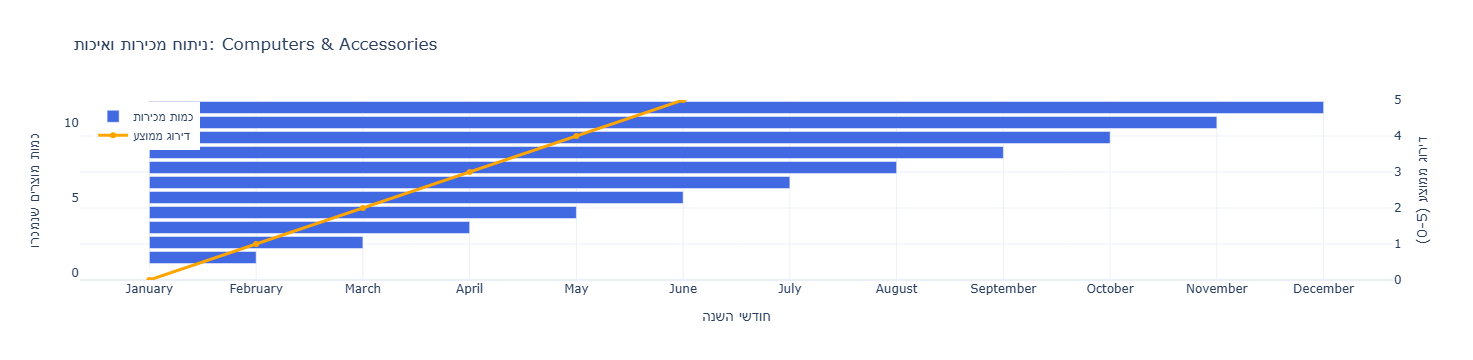

In [14]:
import pandas as pd
import plotly.graph_objects as go

# Load the file directly from the current working directory
df = pd.read_csv('amazon.csv')

print("Amazon File loaded successfully!")
#print(df.head())

shape = df.shape
print(f"Rows: {shape[0]}, Columns: {shape[1]}")

total_rows = len(df)
print(f"Total Records: {total_rows}")

#### Data Cleaning ####
# Remove duplicates
df = df.drop_duplicates(subset='product_id')
total_rows = len(df)
print(f"Total Records after remove duplicates: {total_rows}")

# Cleaning discounted_price Column: remove Rupee currency , remove comma and convert to float
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)

# Cleaning actual_price Column: remove Rupee currency , remove comma and convert to float
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

# Cleaning rating Column: remove "|" char and convert to numeric
df['rating'] = pd.to_numeric(df['rating'].astype(str).str.replace('|', ''), errors='coerce')
# Cleaning rating_count Column:  remove comma chars and convert to numeric
df['rating_count'] = pd.to_numeric(df['rating_count'].astype(str).str.replace(',', ''), errors='coerce')
# Cleaning discount_percentage Column:  remove % chars and convert to numeric
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)/100
# Create a new Category
df['main_category'] = df['category'].str.split('|').str[0]

print(df.head())

#kpi
print("KPI:")
# סינון ה-DataFrame לפי הקטגוריה המבוקשת
computers_df = df[df['main_category'] == 'Computers&Accessories']
# חישוב הכמות
count = len(computers_df)
print(f"Number of products in Computers&Accessories: {count}")

# 1. סינון הנתונים לקטגוריה הרצויה בלבד
computers_df = df[df['main_category'] == 'Computers&Accessories']

# 2. חישוב הממוצע של עמודת הדירוג (rating)
average_rating = computers_df['rating'].mean()
print(f"Average Rating for Computers&Accessories: {average_rating:.2f}")

### 3



# 1. הכנת הנתונים - וודא שעמודת התאריך מזוהה כראוי
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['month_num'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%B')

# 2. סינון לקטגוריה וקיבוץ נתונים (אגרגציה)
comp_df = df[df['main_category'] == 'Computers&Accessories']
monthly_stats = comp_df.groupby(['month_num', 'month_name']).agg({
    'product_id': 'count', 
    'rating': 'mean'
}).reset_index().sort_values('month_num')

# 3. יצירת הגרף
fig = go.Figure()

# הוספת העמודות (המלבנים) לכמות המכירות
fig.add_trace(go.Bar(
    x=monthly_stats['month_name'],
    y=monthly_stats['product_id'],
    name='כמות מכירות',
    marker_color='royalblue',
    text=monthly_stats['product_id'],
    textposition='outside' # מציג את המספר מעל המלבן
))

# הוספת קו ממוצע הדירוג על ציר Y משני (ימני)
fig.add_trace(go.Scatter(
    x=monthly_stats['month_name'],
    y=monthly_stats['rating'],
    name='דירוג ממוצע',
    mode='lines+markers',
    yaxis='y2',
    line=dict(color='orange', width=3)
))

# 4. עיצוב הצירים והגרף
fig.update_layout(
    title='ניתוח מכירות ואיכות: Computers & Accessories',
    xaxis_title='חודשי השנה',
    yaxis_title='כמות מוצרים שנמכרו',
    yaxis2=dict(
        title='דירוג ממוצע (0-5)',
        overlaying='y',
        side='right',
        range=[0, 5]
    ),
    legend=dict(x=0.01, y=0.99),
    template='plotly_white'
)

fig.show()


